In [2]:
import matplotlib.pyplot as plt 
import numpy as np
from PIL import Image
#from devernay_edges import DevernayEdges
from PIL import Image, ImageFilter, ImageOps, ImageEnhance
import cv2
import imageio as iio
import matplotlib.pyplot as plt
import skimage.feature as feature
import sys
import scipy.ndimage as ndi
from scipy import optimize
#from ellipse import LsqEllipse
import statistics
from statistics import mean 
from skimage.measure import EllipseModel
from matplotlib.patches import Ellipse
import pandas as pd
import os
from math import pi
from PIL import Image


In [3]:
import skimage
print(skimage.__version__)

0.19.3


In [4]:
def plot_image(image_1, image_2,title_1="Orignal", title_2="New Image"):
    plt.figure(figsize=(10,10))
    plt.subplot(1, 2, 1)
    plt.imshow(image_1,cmap="gray")
    plt.title(title_1)
    plt.subplot(1, 2, 2)
    plt.imshow(image_2,cmap="gray")
    plt.title(title_2)
    plt.show()

In [5]:
def echter_edger(file1):
    imgcv = cv2.imread(file1)
    eq = cv2.imread(file1,cv2.IMREAD_GRAYSCALE)
    new_image = cv2.equalizeHist(eq)
#    plot_image(imgcv, new_image,title_1="Orignal", title_2="New Image")
    image = new_image
    image = ndi.gaussian_filter(image, 1.5)
#   edges2=ndi.binary_closing(edges2)
    edges1 = feature.canny(image)
    edges2 = feature.canny(image, sigma=7.1)

    plot_image(edges1, edges2,title_1="Orignal", title_2="New Image")
    return imgcv,eq,edges1,edges2


In [6]:
def Elpise_Filter(Matrix):
#281.2135 pixel/mm
    scale=1/281.2135
    #DELETING ANNOYING LINES
    Matrix[790:799,:]=False
    Matrix[0:10,:]=False
    #eXTRACTING THE coordinates of the edges
    s = np.shape(Matrix)
    ones=np.ones(s)
    mass_x, mass_y = np.where(ones ==1)
    s = np.shape(np.transpose(Matrix))
    ones=np.ones(s)
    nx, ny = s
    x = np.linspace(0, nx, nx)
    y = np.linspace(0,  ny, ny)
    xx, yy = np.meshgrid(x, y)
    X=np.array(xx[Matrix],dtype='int')
    Y= np.array(yy[Matrix],dtype='int')
    cent_x = np.average(X)
    cent_y = np.average(Y)
    points=np.hstack([X[:, np.newaxis], Y[:, np.newaxis]])
    a_points = points
    x = xx[Matrix]
    y = yy[Matrix]
#    plt.rcParams["figure.figsize"] = (15,8)
#    plt.plot(X, Y, marker='.', color='k', linestyle='none')
#    plt.plot(cent_x,cent_y,'ro:')
#-------------------------------------------
    ell = EllipseModel()
    ell.estimate(a_points)
    xc, yc, a, b, theta = ell.params
    xc, yc, a, b=xc*scale, yc*scale, a*scale, b*scale
    print("center = ",  (xc, yc))
    print("angle of rotation = ",  theta)
    print("axes = ", (a,b))
    fig, axs = plt.subplots(2, 1, sharex=True, sharey=True)
    axs[0].scatter(x*scale,y*scale)
    axs[1].scatter(x*scale, y*scale)
    axs[1].scatter(xc, yc, color='red', s=100)
    ell_patch = Ellipse((xc, yc), 2*a, 2*b, theta*180/np.pi, edgecolor='red', facecolor='none')
    axs[1].add_patch(ell_patch)
    plt.show()
    return X,Y,xc, yc, a, b, theta,scale

In [9]:
def echter_edger(file1,sig):
    imgcv = cv2.imread(file1)
    eq = cv2.imread(file1,cv2.IMREAD_GRAYSCALE)
    new_image = cv2.equalizeHist(eq)
#    plot_image(imgcv, new_image,title_1="Orignal", title_2="New Image")
    image = new_image
    image = ndi.gaussian_filter(image, 3)
#   edges2=ndi.binary_closing(edges2)
    edges1 = feature.canny(image)
    edges2 = feature.canny(image, sigma=sig)

    plot_image(edges1, edges2,title_1="Orignal", title_2="New Image")
    return imgcv,eq,edges1,edges2


In [14]:
# Get the list of all files and directories
path = r"C:\Users\Diego\Desktop\Snapshots\06.03.2023"
save=r"C:\Users\Diego\Desktop\Snapshots\06.03.2023\edges"
dir_list = os.listdir(path)
os.chdir(save)
i=1
centrox=[]
centroy=[]
centro_x=[]
centro_y=[]
mayor=[]
minor=[]
thetah=[]
distance=[]
Perimeter=[]
Area=[]
XX=[]
YY=[]
for name in dir_list:
    spm=list(name)[-3:]
    s=""
    spm=s.join(spm)
    filenamesave =save
    i+=1
    if spm=="tif":
            filename=path+"/"+name # prints all files
            print(filename)
            imgcv,eq,edges1,edges2=echter_edger(filename,5)
            X,Y,xc, yc, a, b,theta,scale= theta=Elpise_Filter(edges2)
            centrox.append(xc)
            centroy.append(yc)
            centro_x.append(xc/scale)
            centro_y.append(yc/scale)
            mayor.append(a)
            minor.append(b)
            XX.append(X)
            YY.append(Y)
            thetah.append(theta)
            sqare=(centrox[0]-xc)**2+(centroy[0]-yc)**2
            d=np.sqrt(sqare)
            distance.append(d)
            P=np.sqrt(a+b)*3.14
            A=a*b*3.14
            Perimeter.append(P)
            Area.append(A)
            data = {
  "Center_X": centrox,
  "Center_Y": centroy, 
    "Mayor Ax":mayor,
    "Minor":minor,
    "theta":thetah            
    
}
            plt.plot(X,Y, ".", color='red',  markersize=0.5)
            plt.plot(centro_x,centro_y, ".", color='green')                
            plt.imshow(imgcv,cmap="gray")
            plt.show()
            plt.savefig(filenamesave+'\\'+str(i)+'.png')
            
            for i in range(len(XX)-1):
                plt.plot(XX[i],YY[i], ".",  markersize=0.5)

            
            plt.plot(centro_x,centro_y, ".", color='green')                
            plt.imshow(imgcv,cmap="gray")
            plt.savefig(filenamesave+'\\'+str(i)+"super"+'.png')
#load data into a DataFrame object:
df = pd.DataFrame(data)
print(df)  
 # prints all files
 # prints all files

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\Diego\\Desktop\\Snapshots\\06.03.2023'

In [15]:
plt.plot(np.arange(0,len(data["Center_X"])),data["Center_X"])
plt.title("x displacement")
plt.xlabel("t[min]")
plt.ylabel("distance[mm]")
plt.show()
plt.plot(np.arange(0,len(data["Center_X"])),data["Center_Y"])
plt.title("y displacement")
plt.xlabel("t[min]")
plt.ylabel("distance[mm]")
plt.show()
plt.plot(np.arange(0,len(data["Center_X"])),distance)
plt.title("Displacement")
plt.xlabel("t[min]")
plt.ylabel("Distance[mm]")
plt.show()
plt.plot(np.arange(0,len(data["Center_X"])),Perimeter)
plt.title("Perimeter vs Time")
plt.xlabel("t[min]")
plt.ylabel("Perimeter[mm]")
plt.show()
plt.plot(np.arange(0,len(data["Center_X"])),Area)
plt.title("Area vs Time")
plt.xlabel("t[min]")
plt.ylabel("Area[$mm^2$]")
plt.show()

NameError: name 'data' is not defined

In [16]:
# Get the list of all files and directories
path = r"C:\Users\Diego\Desktop\Snapshots\07.03.2023"
save=r"C:\Users\Diego\Desktop\Snapshots\07.03.2023\edges"
dir_list = os.listdir(path)
os.chdir(save)
i=1
centrox=[]
centroy=[]
centro_x=[]
centro_y=[]
mayor=[]
minor=[]
thetah=[]
distance=[]
Perimeter=[]
Area=[]
XX=[]
YY=[]
for name in dir_list:
    spm=list(name)[-3:]
    s=""
    spm=s.join(spm)
    filenamesave =save
    i+=1
    if spm=="tif":
            filename=path+"/"+name # prints all files
            print(filename)
            imgcv,eq,edges1,edges2=echter_edger(filename,5)
            X,Y,xc, yc, a, b,theta,scale= theta=Elpise_Filter(edges2)
            centrox.append(xc)
            centroy.append(yc)
            centro_x.append(xc/scale)
            centro_y.append(yc/scale)
            mayor.append(a)
            minor.append(b)
            XX.append(X)
            YY.append(Y)
            thetah.append(theta)
            sqare=(centrox[0]-xc)**2+(centroy[0]-yc)**2
            d=np.sqrt(sqare)
            distance.append(d)
            P=np.sqrt(a+b)*3.14
            A=a*b*3.14
            Perimeter.append(P)
            Area.append(A)
            data = {
  "Center_X": centrox,
  "Center_Y": centroy, 
    "Mayor Ax":mayor,
    "Minor":minor,
    "theta":thetah            
    
}
            plt.plot(X,Y, ".", color='red',  markersize=0.5)
            plt.plot(centro_x,centro_y, ".", color='green')                
            plt.imshow(imgcv,cmap="gray")
            plt.show()
            plt.savefig(filenamesave+'\\'+str(i)+'.png')
            
            for i in range(len(XX)-1):
                plt.plot(XX[i],YY[i], ".",  markersize=0.5)

            
            plt.plot(centro_x,centro_y, ".", color='green')                
            plt.imshow(imgcv,cmap="gray")
            plt.savefig(filenamesave+'\\'+str(i)+"super"+'.png')
#load data into a DataFrame object:
df = pd.DataFrame(data)
print(df)  
 # prints all files
 # prints all files

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\Diego\\Desktop\\Snapshots\\07.03.2023'

In [17]:
for i in range(len(XX)-1):
    plt.plot(XX[i],YY[i], ".",  markersize=0.5)


In [18]:
plt.plot(np.arange(0,len(data["Center_X"])),data["Center_X"])
plt.title("x displacement")
plt.xlabel("t[min]")
plt.ylabel("distance[mm]")
plt.show()
plt.plot(np.arange(0,len(data["Center_X"])),data["Center_Y"])
plt.title("y displacement")
plt.xlabel("t[min]")
plt.ylabel("distance[mm]")
plt.show()
plt.plot(np.arange(0,len(data["Center_X"])),distance)
plt.title("Displacement")
plt.xlabel("t[min]")
plt.ylabel("Distance[mm]")
plt.show()
plt.plot(np.arange(0,len(data["Center_X"])),Perimeter)
plt.title("Perimeter vs Time")
plt.xlabel("t[min]")
plt.ylabel("Perimeter[mm]")
plt.show()
plt.plot(np.arange(0,len(data["Center_X"])),Area)
plt.title("Area vs Time")
plt.xlabel("t[min]")
plt.ylabel("Area[$mm^2$]")
plt.show()

NameError: name 'data' is not defined

In [62]:
def echter_edger(file1,sig):
    eq = np.array(Image.open(file1))
    #eq = cv2.imread(file1,0)
    # = cv2.equalizeHist(eq)

    image = eq
    new_image= ndi.gaussian_filter(image, 2)
    plot_image(eq, new_image,title_1="Orignal", title_2="New Image")
    #   edges2=ndi.binary_closing(edges2)
    edges1 = feature.canny(image)
    edges2 = feature.canny(image, sigma=sig)

    plot_image(edges1, edges2,title_1="Orignal", title_2="New Image")
    return imgcv,eq,edges1,edges2

C:\Users\cortesd\Documents\Fastcam\20.05.2023\50µm PS 40deg/27506_2763.tif


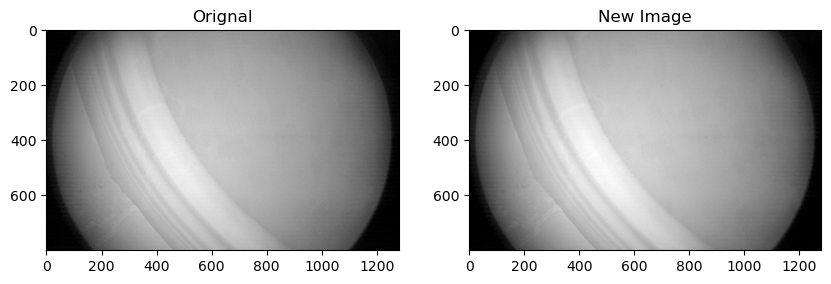

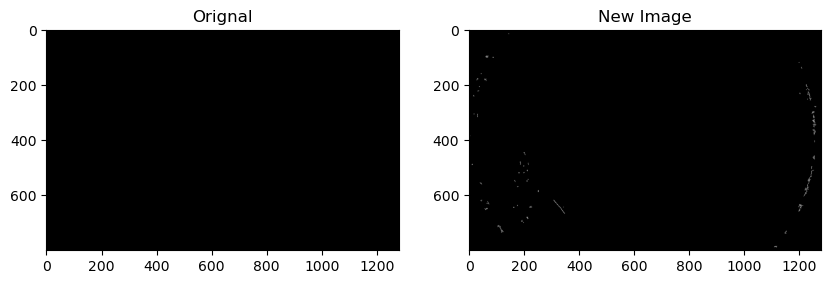

center =  (2.2918223210321713, 1.3868261095825318)
angle of rotation =  0.09362230770226881
axes =  (2.240959784261461, 1.5156499475680463)


C:\Users\cortesd\AppData\Local\Temp\ipykernel_21540\3729675066.py:40: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  ell_patch = Ellipse((xc, yc), 2*a, 2*b, theta*180/np.pi, edgecolor='red', facecolor='none')


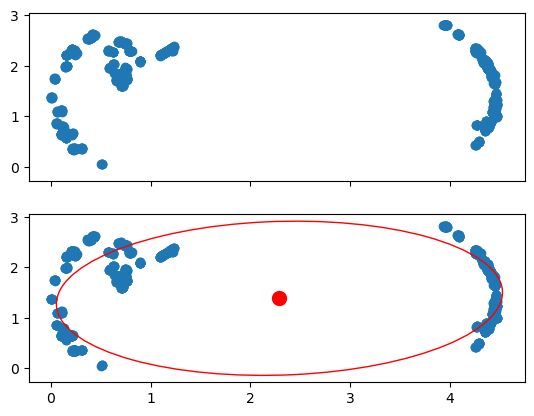

TypeError: Image data of dtype object cannot be converted to float

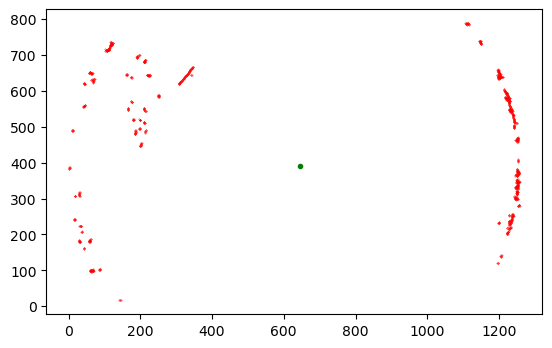

In [64]:
# Get the list of all files and directories
path = r"C:\Users\cortesd\Documents\Fastcam\20.05.2023\50µm PS 40deg"
save=r"C:\Users\cortesd\Documents\Fastcam\20.05.2023\50µm PS 40deg\edges"
dir_list = os.listdir(path)
os.chdir(save)
i=1
centrox=[]
centroy=[]
centro_x=[]
centro_y=[]
mayor=[]
minor=[]
thetah=[]
distance=[]
Perimeter=[]
Area=[]
XX=[]
YY=[]
for name in dir_list:
    spm=list(name)[-3:]
    s=""
    spm=s.join(spm)
    filenamesave =save
    i+=1
    if spm=="tif":
            filename=path+"/"+name # prints all files
            print(filename)
            imgcv,eq,edges1,edges2=echter_edger(filename,0.1)
            X,Y,xc, yc, a, b,theta,scale= theta=Elpise_Filter(edges2)
            centrox.append(xc)
            centroy.append(yc)
            centro_x.append(xc/scale)
            centro_y.append(yc/scale)
            mayor.append(a)
            minor.append(b)
            XX.append(X)
            YY.append(Y)
            thetah.append(theta)
            sqare=(centrox[0]-xc)**2+(centroy[0]-yc)**2
            d=np.sqrt(sqare)
            distance.append(d)
            P=np.sqrt(a+b)*3.14
            A=a*b*3.14
            Perimeter.append(P)
            Area.append(A)
            data = {
  "Center_X": centrox,
  "Center_Y": centroy, 
    "Mayor Ax":mayor,
    "Minor":minor,
    "theta":thetah            
    
}
            plt.plot(X,Y, ".", color='red',  markersize=0.5)
            plt.plot(centro_x,centro_y, ".", color='green')                
            plt.imshow(imgcv,cmap="gray")
            plt.show()
            plt.savefig(filenamesave+'\\'+str(i)+'.png')
            
            for i in range(len(XX)-1):
                plt.plot(XX[i],YY[i], ".",  markersize=0.5)

            
            plt.plot(centro_x,centro_y, ".", color='green')                
            plt.imshow(imgcv,cmap="gray")
            plt.savefig(filenamesave+'1\\'+str(i)+"super"+'.png')
#load data into a DataFrame object:
df = pd.DataFrame(data)
print(df)  
 # prints all files
 # prints all files

plt.plot(np.arange(0,len(data["Center_X"])),data["Center_X"])
plt.title("x displacement")
plt.xlabel("t[min]")
plt.ylabel("distance[mm]")
plt.show()
plt.plot(np.arange(0,len(data["Center_X"])),data["Center_Y"])
plt.title("y displacement")
plt.xlabel("t[min]")
plt.ylabel("distance[mm]")
plt.show()
plt.plot(np.arange(0,len(data["Center_X"])),distance)
plt.title("Displacement")
plt.xlabel("t[min]")
plt.ylabel("Distance[mm]")
plt.show()
plt.plot(np.arange(0,len(data["Center_X"])),Perimeter)
plt.title("Perimeter vs Time")
plt.xlabel("t[min]")
plt.ylabel("Perimeter[mm]")
plt.show()
plt.plot(np.arange(0,len(data["Center_X"])),Area)
plt.title("Area vs Time")
plt.xlabel("t[min]")
plt.ylabel("Area[$mm^2$]")
plt.show()

In [ ]:
plt.plot(np.arange(0,len(data["Center_X"])),data["Center_X"])
plt.title("x displacement")
plt.xlabel("t[min]")
plt.ylabel("distance[mm]")
plt.show()
plt.plot(np.arange(0,len(data["Center_X"])),data["Center_Y"])
plt.title("y displacement")
plt.xlabel("t[min]")
plt.ylabel("distance[mm]")
plt.show()
plt.plot(np.arange(0,len(data["Center_X"])),distance)
plt.title("Displacement")
plt.xlabel("t[min]")
plt.ylabel("Distance[mm]")
plt.show()
plt.plot(np.arange(0,len(data["Center_X"])),Perimeter)
plt.title("Perimeter vs Time")
plt.xlabel("t[min]")
plt.ylabel("Perimeter[mm]")
plt.show()
plt.plot(np.arange(0,len(data["Center_X"])),Area)
plt.title("Area vs Time")
plt.xlabel("t[min]")
plt.ylabel("Area[$mm^2$]")
plt.show()

In [ ]:
# Get the list of all files and directories
path = r"C:\Users\Diego\Desktop\Snapshots\Test1\Calibration01\27506\20.03.2023"
save=r"C:\Users\Diego\Desktop\Snapshots\Test1\Calibration01\27506\20.03.2023\edges"
dir_list = os.listdir(path)
os.chdir(save)
i=1
centrox=[]
centroy=[]
centro_x=[]
centro_y=[]
mayor=[]
minor=[]
thetah=[]
distance=[]
Perimeter=[]
Area=[]
XX=[]
YY=[]
for name in dir_list[3:]:
    spm=list(name)[-3:]
    s=""
    spm=s.join(spm)
    filenamesave =save
    i+=1
    if spm=="tif":
            filename=path+"/"+name # prints all files
            print(filename)
            imgcv,eq,edges1,edges2=echter_edger(filename,5)
            X,Y,xc, yc, a, b, theta,scale=Elpise_Filter(edges2)
            XX.append(X)
            YY.append(Y)
            centrox.append(xc)
            centroy.append(yc)
            centro_x.append(xc/scale)
            centro_y.append(yc/scale)
            mayor.append(a)
            minor.append(b)
            thetah.append(theta)
            sqare=(centrox[0]-xc)**2+(centroy[0]-yc)**2
            d=np.sqrt(sqare)
            distance.append(d)
            P=np.sqrt(a+b)*3.14
            A=a*b*3.14
            Perimeter.append(P)
            Area.append(A)
            data = {
  "Center_X": centrox,
  "Center_Y": centroy, 
    "Mayor Ax":mayor,
    "Minor":minor,
    "theta":thetah            
    
}
            plt.plot(X,Y, ".", color='red',  markersize=0.5)
            plt.plot(centro_x,centro_y, ".", color='green')                
            plt.imshow(imgcv,cmap="gray")
            plt.show()
            plt.savefig(filenamesave+'\\'+str(i)+'.png')
            
            for i in range(len(XX)-1):
                plt.plot(XX[i],YY[i], ".",  markersize=0.5)

            
            plt.plot(centro_x,centro_y, ".", color='green')                
            plt.imshow(imgcv,cmap="gray")
            plt.savefig(filenamesave+'\\_'+str(i)+"super"+'.png')
#load data into a DataFrame object:
df = pd.DataFrame(data)
print(df)  
 # prints all files
 # prints all files

In [ ]:
# Get the list of all files and directories
path = r"C:\Users\Diego\Desktop\Snapshots\Test1\Calibration01\27506\21.03.2023"
save=r"C:\Users\Diego\Desktop\Snapshots\Test1\Calibration01\27506\21.03.2023\edges"
dir_list = os.listdir(path)
os.chdir(save)
i=1
centrox=[]
centroy=[]
centro_x=[]
centro_y=[]
mayor=[]
minor=[]
thetah=[]
distance=[]
Perimeter=[]
Area=[]
XX=[]
YY=[]
for name in dir_list:
    spm=list(name)[-3:]
    s=""
    spm=s.join(spm)
    filenamesave =save
    i+=1
    if spm=="tif":
            filename=path+"/"+name # prints all files
            print(filename)
            imgcv,eq,edges1,edges2=echter_edger(filename,4)
            cut=950
            imgcv,eq,edges1,edges2=imgcv[:, :cut],eq[:, :cut],edges1[:, :cut],edges2[:, :cut]
            X,Y,xc, yc, a, b,theta,scale= theta=Elpise_Filter(edges2)
             
            centrox.append(xc)
            centroy.append(yc)
            centro_x.append(xc/scale)
            centro_y.append(yc/scale)
            mayor.append(a)
            minor.append(b)
            XX.append(X)
            YY.append(Y)
            thetah.append(theta)
            sqare=(centrox[0]-xc)**2+(centroy[0]-yc)**2
            d=np.sqrt(sqare)
            distance.append(d)
            P=np.sqrt(a+b)*3.14
            A=a*b*3.14
            Perimeter.append(P)
            Area.append(A)
            data = {
  "Center_X": centrox,
  "Center_Y": centroy, 
    "Mayor Ax":mayor,
    "Minor":minor,
    "theta":thetah            
    
}
            plt.plot(X,Y, ".", color='red',  markersize=0.5)
            plt.plot(centro_x,centro_y, ".", color='green')                
            plt.imshow(imgcv,cmap="gray")
            plt.show()
            plt.savefig(filenamesave+'\\'+str(i)+'.png')
            
            for i in range(len(XX)-1):
                plt.plot(XX[i],YY[i], ".",  markersize=0.5)

            
            plt.plot(centro_x,centro_y, ".", color='green')                
            plt.imshow(imgcv,cmap="gray")
            plt.savefig(filenamesave+'\\_'+str(i)+"super"+'.png')
#load data into a DataFrame object:
df = pd.DataFrame(data)
print(df)  
 # prints all files
 # prints all files

In [ ]:
# Get the list of all files and directories
path = r"C:\Users\Diego\Desktop\Snapshots\Test1\Calibration01\27506\28.03.2023"
save=r"C:\Users\Diego\Desktop\Snapshots\Test1\Calibration01\27506\28.03.2023\edges"
dir_list = os.listdir(path)
os.chdir(save)
i=1
centrox=[]
centroy=[]
centro_x=[]
centro_y=[]
mayor=[]
minor=[]
thetah=[]
distance=[]
Perimeter=[]
Area=[]
XX=[]
YY=[]
for name in dir_list:
    spm=list(name)[-3:]
    s=""
    spm=s.join(spm)
    filenamesave =save
    i+=1
    if spm=="tif":
            filename=path+"/"+name # prints all files
            print(filename)
            imgcv,eq,edges1,edges2=echter_edger(filename,3)
            cut=950
            imgcv,eq,edges1,edges2=imgcv[:, :cut],eq[:, :cut],edges1[:, :cut],edges2[:, :cut]
            X,Y,xc, yc, a, b,theta,scale= theta=Elpise_Filter(edges2)
             
            centrox.append(xc)
            centroy.append(yc)
            centro_x.append(xc/scale)
            centro_y.append(yc/scale)
            mayor.append(a)
            minor.append(b)
            XX.append(X)
            YY.append(Y)
            thetah.append(theta)
            sqare=(centrox[0]-xc)**2+(centroy[0]-yc)**2
            d=np.sqrt(sqare)
            distance.append(d)
            P=np.sqrt(a+b)*3.14
            A=a*b*3.14
            Perimeter.append(P)
            Area.append(A)
            data = {
  "Center_X": centrox,
  "Center_Y": centroy, 
    "Mayor Ax":mayor,
    "Minor":minor,
    "theta":thetah            
    
}
            plt.plot(X,Y, ".", color='red',  markersize=0.5)
            plt.plot(centro_x,centro_y, ".", color='green')                
            plt.imshow(imgcv,cmap="gray")
            plt.show()
            plt.savefig(filenamesave+'\\'+str(i)+'.png')
            
            for i in range(len(XX)-1):
                plt.plot(XX[i],YY[i], ".",  markersize=0.5)

            
            plt.plot(centro_x,centro_y, ".", color='green')                
            plt.imshow(imgcv,cmap="gray")
            plt.savefig(filenamesave+'\\'+str(i)+"super"+'.png')
#load data into a DataFrame object:
df = pd.DataFrame(data)
print(df)  
 # prints all files
 # prints all files

In [ ]:
# Get the list of all files and directories
path = r"C:\Users\Diego\Desktop\Snapshots\Test1\Calibration01\27506\31.03.2023"
save=r"C:\Users\Diego\Desktop\Snapshots\Test1\Calibration01\27506\31.03.2023\edges"
dir_list = os.listdir(path)
os.chdir(save)
i=1
centrox=[]
centroy=[]
centro_x=[]
centro_y=[]
mayor=[]
minor=[]
thetah=[]
distance=[]
Perimeter=[]
Area=[]
XX=[]
YY=[]
for name in dir_list[3:]:
    spm=list(name)[-3:]
    s=""
    spm=s.join(spm)
    filenamesave =save
    i+=1
    if spm=="tif":
            filename=path+"/"+name # prints all files
            print(filename)
            imgcv,eq,edges1,edges2=echter_edger(filename,5)
            X,Y,xc, yc, a, b, theta,scale=Elpise_Filter(edges2)
            XX.append(X)
            YY.append(Y)
            centrox.append(xc)
            centroy.append(yc)
            centro_x.append(xc/scale)
            centro_y.append(yc/scale)
            mayor.append(a)
            minor.append(b)
            thetah.append(theta)
            sqare=(centrox[0]-xc)**2+(centroy[0]-yc)**2
            d=np.sqrt(sqare)
            distance.append(d)
            P=np.sqrt(a+b)*3.14
            A=a*b*3.14
            Perimeter.append(P)
            Area.append(A)
            data = {
  "Center_X": centrox,
  "Center_Y": centroy, 
    "Mayor Ax":mayor,
    "Minor":minor,
    "theta":thetah            
    
}
            plt.plot(X,Y, ".", color='red',  markersize=0.5)
            plt.plot(centro_x,centro_y, ".", color='green')                
            plt.imshow(imgcv,cmap="gray")
            plt.show()
            plt.savefig(filenamesave+'\\'+str(i)+'.png')
            
            for i in range(len(XX)-1):
                plt.plot(XX[i],YY[i], ".",  markersize=0.5)

            
            plt.plot(centro_x,centro_y, ".", color='green')                
            plt.imshow(imgcv,cmap="gray")
            plt.savefig(filenamesave+'\\_'+str(i)+"super"+'.png')
#load data into a DataFrame object:
df = pd.DataFrame(data)
print(df)  
 # prints all files
 # prints all files

C:\Users\cortesd\Documents\Fastcam\20.05.2023\50µm_PS_40deg/27506_2766.tif


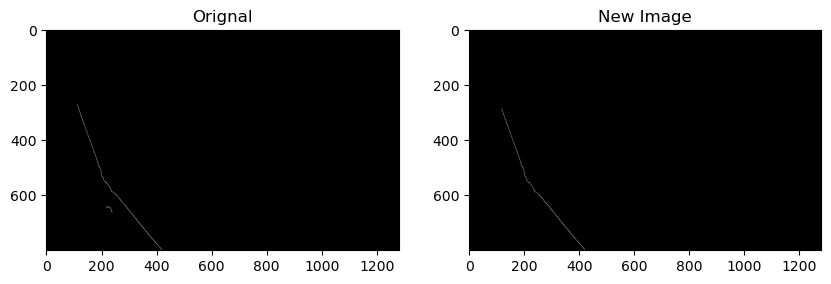

center =  (0.941600642960233, 1.9247370152133139)
angle of rotation =  1.021158563159153
axes =  (0.8414023473817805, 0.14511094589845364)


C:\Users\cortesd\AppData\Local\Temp\ipykernel_17880\3729675066.py:40: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  ell_patch = Ellipse((xc, yc), 2*a, 2*b, theta*180/np.pi, edgecolor='red', facecolor='none')


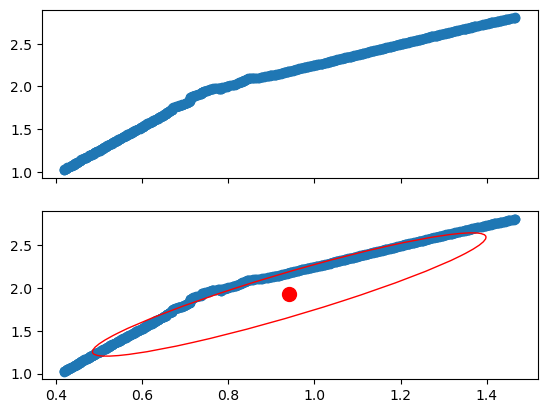

TypeError: Image data of dtype object cannot be converted to float

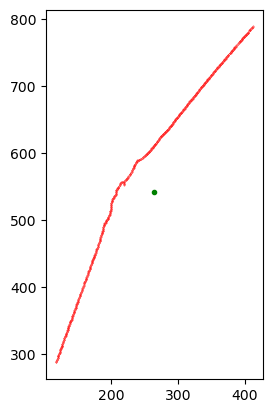

In [13]:
def echter_edger(file1,sig):
    imgcv = cv2.imread(file1)
    eq = plt.imread(file1,cv2.IMREAD_GRAYSCALE)
    new_image = cv2.equalizeHist(eq)
#    plot_image(imgcv, new_image,title_1="Orignal", title_2="New Image")
    image = new_image
    image = ndi.gaussian_filter(image, 1.5)
#   edges2=ndi.binary_closing(edges2)
    edges1 = feature.canny(image)
    edges2 = feature.canny(image, sigma=sig)

    plot_image(edges1, edges2,title_1="Orignal", title_2="New Image")
    return imgcv,eq,edges1,edges2
# Get the list of all files and directories
path = r"C:\Users\cortesd\Documents\Fastcam\20.05.2023\50µm_PS_40deg"
save=r"C:\Users\cortesd\Documents\Fastcam\20.05.2023\50µm_PS_40deg\edges"
dir_list = os.listdir(path)
os.chdir(save)
i=1
centrox=[]
centroy=[]
centro_x=[]
centro_y=[]
mayor=[]
minor=[]
thetah=[]
distance=[]
Perimeter=[]
Area=[]
XX=[]
YY=[]
for name in dir_list[3:]:
    spm=list(name)[-3:]
    s=""
    spm=s.join(spm)
    filenamesave =save
    i+=1
    if spm=="tif":
            filename=path+"/"+name # prints all files
            print(filename)
            imgcv,eq,edges1,edges2=echter_edger(filename,1.5)
            X,Y,xc, yc, a, b, theta,scale=Elpise_Filter(edges2)
            XX.append(X)
            YY.append(Y)
            centrox.append(xc)
            centroy.append(yc)
            centro_x.append(xc/scale)
            centro_y.append(yc/scale)
            mayor.append(a)
            minor.append(b)
            thetah.append(theta)
            sqare=(centrox[0]-xc)**2+(centroy[0]-yc)**2
            d=np.sqrt(sqare)
            distance.append(d)
            P=np.sqrt(a+b)*3.14
            A=a*b*3.14
            Perimeter.append(P)
            Area.append(A)
            data = {
  "Center_X": centrox,
  "Center_Y": centroy, 
    "Mayor Ax":mayor,
    "Minor":minor,
    "theta":thetah            
    
}
            plt.plot(X,Y, ".", color='red',  markersize=0.5)
            plt.plot(centro_x,centro_y, ".", color='green')                
            plt.imshow(imgcv,cmap="gray")
            plt.show()
            plt.savefig(filenamesave+'\\'+str(i)+'.png')
            
            for i in range(len(XX)-1):
                plt.plot(XX[i],YY[i], ".",  markersize=0.5)

            
            plt.plot(centro_x,centro_y, ".", color='green')                
            plt.imshow(imgcv,cmap="gray")
            plt.savefig(filenamesave+'\\_'+str(i)+"super"+'.png')
#load data into a DataFrame object:
df = pd.DataFrame(data)
print(df)  
 # prints all files
 # prints all files